<a href="https://colab.research.google.com/github/Joseonggwan/machine-learning-practice/blob/main/03_knn_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-최근접 이웃 회귀

## 데이터 준비

In [1]:
import numpy as np

In [2]:
# 농어의 길이와 무게
perch_length = np.array(
    [8.4, 13.7, 15.0, 16.2, 17.4, 18.0, 18.7, 19.0, 19.6, 20.0,
     21.0, 21.0, 21.0, 21.3, 22.0, 22.0, 22.0, 22.0, 22.0, 22.5,
     22.5, 22.7, 23.0, 23.5, 24.0, 24.0, 24.6, 25.0, 25.6, 26.5,
     27.3, 27.5, 27.5, 27.5, 28.0, 28.7, 30.0, 32.8, 34.5, 35.0,
     36.5, 36.0, 37.0, 37.0, 39.0, 39.0, 39.0, 40.0, 40.0, 40.0,
     40.0, 42.0, 43.0, 43.0, 43.5, 44.0]
     )
perch_weight = np.array(
    [5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0,
     110.0, 115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0,
     130.0, 150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0,
     197.0, 218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0,
     514.0, 556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0,
     820.0, 850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0,
     1000.0, 1000.0]
     )

In [3]:
import matplotlib.pyplot as plt

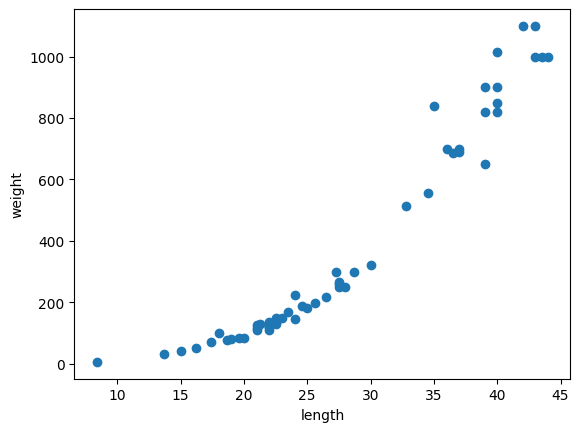

In [4]:
plt.scatter(perch_length, perch_weight)
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
train_input, test_input, train_target, test_target = train_test_split(
    perch_length, perch_weight, random_state=42)

In [7]:
print(train_input.shape, test_input.shape)

(42,) (14,)


In [8]:
test_array = np.array([1,2,3,4])
print(test_array.shape)

(4,)


In [12]:
test_array = test_array.reshape(2, 2)#2x2 행렬로 데이터를 표현
print(test_array.shape)
test_array

(2, 2)


array([[1, 2],
       [3, 4]])

In [11]:
# 아래 코드의 주석을 제거하고 실행하면 에러가 발생합니다
# test_array = test_array.reshape(2, 3)

In [18]:
train_input

array([[19.6],
       [22. ],
       [18.7],
       [17.4],
       [36. ],
       [25. ],
       [40. ],
       [39. ],
       [43. ],
       [22. ],
       [20. ],
       [22. ],
       [24. ],
       [27.5],
       [43. ],
       [40. ],
       [24. ],
       [21. ],
       [27.5],
       [40. ],
       [32.8],
       [26.5],
       [36.5],
       [13.7],
       [22.7],
       [15. ],
       [37. ],
       [35. ],
       [28.7],
       [23.5],
       [39. ],
       [21. ],
       [23. ],
       [22. ],
       [44. ],
       [22.5],
       [19. ],
       [37. ],
       [22. ],
       [25.6],
       [42. ],
       [34.5]])

In [16]:
train_input = train_input.reshape(-1, 1) #-1은 41을 전부 쓸 수 없으니 -1을 써서 전체를 표현
test_input = test_input.reshape(-1, 1)# -1은 전체를 표현

In [17]:
print(train_input.shape, test_input.shape)

(42, 1) (14, 1)


## 결정 계수 ($ R^2$)

In [44]:
from sklearn.neighbors import KNeighborsRegressor #회귀모델사용 이전에 사용한 모델은 분류모델임

In [45]:
knr = KNeighborsRegressor()
# k-최근접 이웃 회귀 모델을 훈련합니다
knr.fit(train_input, train_target)

KNeighborsRegressor()

In [26]:
knr.score(test_input, test_target) #어떤 평가지표를 사용하는지에 따라 점수가 달라진다

0.992809406101064

In [46]:
from sklearn.metrics import mean_absolute_error #우리가 예측한 y값과 실제y값의 차이의 절댓값 확인

In [47]:
# 테스트 세트에 대한 예측을 만듭니다
test_prediction = knr.predict(test_input)
# 테스트 세트에 대한 평균 절댓값 오차를 계산합니다
mae = mean_absolute_error(test_target, test_prediction)
print(mae)

19.157142857142862


## 과대적합 vs 과소적합

In [48]:
print(knr.score(train_input, train_target)) # 학습을 시켰을 때 96%, 평가를 하였을 때 99% -> 과소평가 (학습이 덜 되었다.)

0.9698823289099254


In [49]:
# 이웃의 갯수를 3으로 설정합니다
knr.n_neighbors = 3
# 모델을 다시 훈련합니다
knr.fit(train_input, train_target)
print(knr.score(train_input, train_target))


0.9804899950518966


In [38]:
print(knr.score(test_input, test_target))

0.9746459963987609


## 확인문제

#### 1.물음표 채우기

#### 2. 아래 내용에 대한 답을 적어보세요
- n이 커질수록 모델은 (복잡해진다 / 단순해진다)

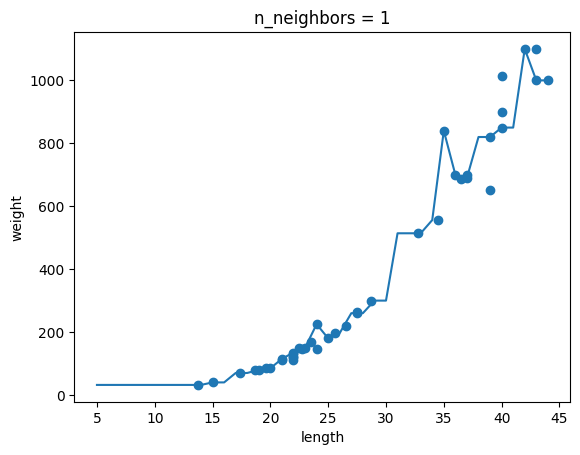

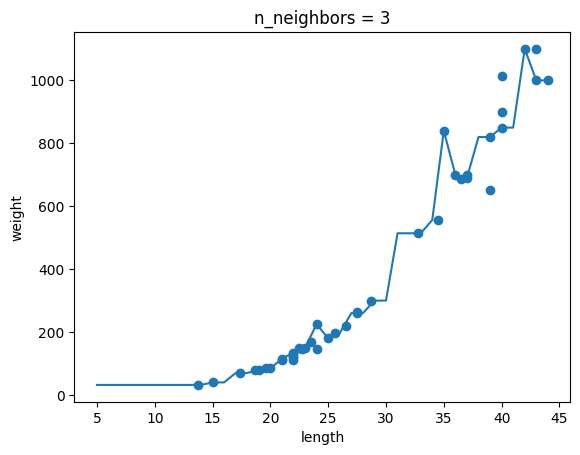

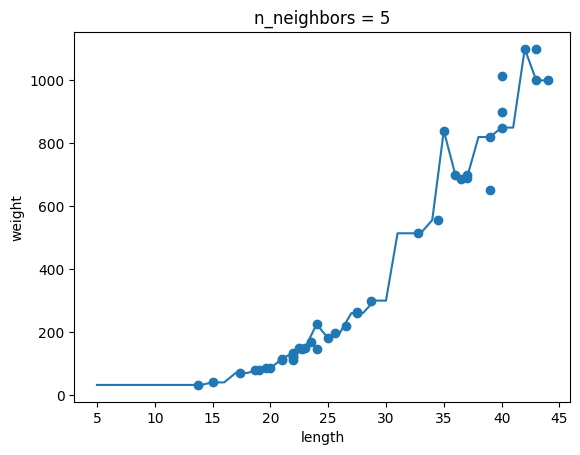

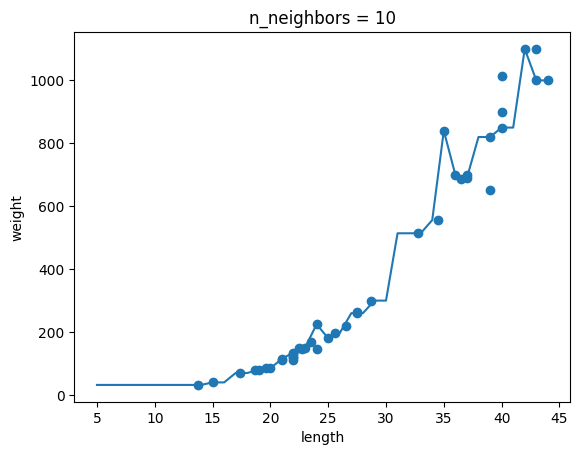

In [57]:
# k-최근접 이웃 회귀 객체를 만듭니다
knr = KNeighborsRegressor()
# 5에서 45까지 x 좌표를 만듭니다
x = np.arange(5, 45).reshape(-1, 1)

# n = 1, 3, 5, 10일 때 예측 결과를 그래프로 그립니다.
for n in [1, 3, 5, 10]:
    # 모델 훈련
    knr.n_neighbors = 1
    knr.fit(train_input, train_target)
    # 지정한 범위 x에 대한 예측 구하기
    prediction =  knr.predict(x)
    # 훈련 세트와 예측 결과 그래프 그리기
    plt.scatter(train_input, train_target)
    plt.plot(x, prediction)
    plt.title(f'n_neighbors = {n}')
    plt.xlabel('length')
    plt.ylabel('weight')
    plt.show()

    #n이 커질수록 모델은 단순해진다. n이 커질수록 평균을 내지만 n이 작을수록 데이터 하나하나 따라가기 때문에 n이 커질수록 모델은 단순해진다.

In [52]:
train_input.shape

(42, 1)

In [53]:
test_input.shape

(14, 1)

In [54]:
train_target.shape

(42,)

In [55]:
test_target.shape

(14,)